# Viscosity of Oxide Glasses — SACF vs Helfand Tutorial

This notebook demonstrates two complementary methods for computing the shear viscosity
of oxide glass melts from classical MD simulations using the **amorphouspy** package.

---

## Physical background

### Green-Kubo / Stress Autocorrelation Function (SACF)

The shear viscosity is related to the integral of the stress autocorrelation function
through the Green-Kubo relation:

$$
\eta = \frac{V}{k_B T} \int_0^{\tau_{\mathrm{cut}}} \langle P_{\alpha\beta}(0)\, P_{\alpha\beta}(t) \rangle \, dt
$$

where $P_{\alpha\beta}$ is an off-diagonal stress component ($xy$, $xz$, $yz$), $V$ is the
simulation volume, and $\tau_{\mathrm{cut}}$ is the integration cutoff — the time at which
the SACF has decayed to noise.

**Key parameter:** The cutoff $\tau_{\mathrm{cut}}$ must be chosen carefully. Too short → η
under-estimated. Too long → noise dominates. `amorphouspy` provides three automatic cutoff
detection methods: `noise_threshold`, `cumulative_integral`, and `self_consistent`
(Chodera-style).

### Helfand Moment Method

Instead of integrating the SACF, the Helfand method accumulates stress into a **Helfand moment**:

$$
\chi_{\alpha\beta}(t) = \int_0^t P_{\alpha\beta}(t') \, dt'
$$

The viscosity is extracted from the long-time slope of the mean-square displacement of $\chi$:

$$
\eta = \frac{V}{2 k_B T} \lim_{t \to \infty} \frac{d}{dt} \langle [\chi_{\alpha\beta}(t) - \chi_{\alpha\beta}(0)]^2 \rangle
$$

No cutoff is needed — the slope is fitted once the MSD enters the diffusive (linear) regime.

### Maxwell relation

The infinite-frequency shear modulus $G_\infty$ and the Maxwell relaxation time $\tau_M$ are
related to viscosity by:

$$
\tau_M = \frac{\eta}{G_\infty}
$$

For a liquid, $\tau_M$ is in the picosecond range at high temperatures (note: $G_\infty \neq 0$
even for liquids — it is the **instantaneous** elastic modulus, not the static one).

---

## Method comparison

| | Green-Kubo (SACF) | Helfand |
|---|---|---|
| **Formula** | GK integral of SACF | MSD slope of $\chi(t)$ |
| **Cutoff needed?** | Yes — requires $\tau_{\mathrm{cut}}$ | No |
| **Preferred when** | Short trajectories, low-viscosity melts | High-viscosity / long $\tau_{\mathrm{acf}}$ |
| **Extra outputs** | SACF, $\tau_{\mathrm{acf}}$ | $G_\infty$, $\tau_M$, bulk viscosity |
| **amorphouspy function** | `get_viscosity()` | `helfand_viscosity()` |

---

## Workflow overview

```
1. Generate structure + potential
2. viscosity_simulation()   ← Langevin pre-equil → NVT equil → iterative NVT production
                               stores raw pressures in result["result"]["pressures"]
3a. get_viscosity()         ← SACF cutoff method
3b. helfand_viscosity()     ← Helfand MSD slope method
4. viscosity_ensemble()     ← N replicas → mean ± SEM
5. fit_vft()                ← (optional) temperature scan + VFT fit
```

> **Note on demo parameters:** The simulation parameters used in this notebook
> (`initial_production_steps=10_000`, `max_total_time_ns=0.1`) are intentionally short
> so cells complete in seconds. Production runs for converged viscosity require
> **10–100 ns** of trajectory data. Results from demo runs are illustrative only.


## 1. Imports

In [2]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
from executorlib import SingleNodeExecutor

from amorphouspy import (
    generate_potential,
    get_ase_structure,
    get_structure_dict,
    get_viscosity,
    viscosity_ensemble,
    viscosity_simulation,
)
from amorphouspy.workflows.viscosity import helfand_viscosity

warnings.filterwarnings("ignore")

## 2. System setup

We build a 500-atom **CaO–Na₂O–SiO₂** glass (composition: 15 mol% CaO, 18 mol% Na₂O,
67 mol% SiO₂) using the PMMCS interatomic potential. The same structure and potential
are reused for all sections below.

- `get_structure_dict` resolves the composition into atom counts and estimates the
  density using empirical mixing rules.
- `get_ase_structure` creates a random initial configuration.
- `generate_potential` assembles the LAMMPS potential DataFrame for PMMCS.

In [5]:
with SingleNodeExecutor(plot_dependency_graph=False) as exe:
    atoms_dict_future = exe.submit(
        get_structure_dict,
        composition={"CaO": 15, "Na2O": 18, "SiO2": 67},
        target_atoms=300,
        mode="molar",
    )
    structure_future = exe.submit(
        get_ase_structure,
        atoms_dict=atoms_dict_future,
    )
    potential_future = exe.submit(
        generate_potential,
        atoms_dict=atoms_dict_future,
        potential_type="pmmcs",
    )
    atoms_dict = atoms_dict_future.result()
    structure = structure_future.result()
    potential = potential_future.result()

print(f"Atoms: {len(structure)}")
print(f"Species: {set(structure.get_chemical_symbols())}")
print(f"Cell volume: {structure.get_volume():.1f} Å³")

Atoms: 299
Species: {'Na', 'Si', 'O', 'Ca'}
Cell volume: 4062.1 Å³


## 3. Running a single viscosity simulation

`viscosity_simulation` is the top-level function that:

1. Pre-equilibrates the melt with **Langevin dynamics** (short NVT, 10 000 steps) to
   rapidly randomise velocities.
2. Performs a **NVT equilibration** run (10 000 steps) with a standard Nosé–Hoover thermostat.
3. Runs an **iterative NVT production** loop, starting with `initial_production_steps` steps
   and extending by 100 ps at a time until Helfand viscosity converges (relative change
   `< eta_rel_tol` for `eta_stable_iters` consecutive iterations) or the time budget
   `max_total_time_ns` is exhausted.

All raw pressure tensor data is accumulated in `result["result"]["pressures"]` (shape
`[N_frames, 3, 3]`, units GPa) so it can be post-processed by either analysis function.

> **Production tip:** For a converged viscosity at 3000 K in a 500-atom CaO–Na₂O–SiO₂
> glass, use `initial_production_steps=10_000_000` (10 ns) and `max_total_time_ns=50`.

In [6]:
with SingleNodeExecutor(cache_directory="./tutorial_cache") as exe:
    sim_future = exe.submit(
        viscosity_simulation,
        structure=structure,
        potential=potential,
        temperature_sim=2500,
        timestep=1.0,
        initial_production_steps=10_000,  # demo: use ≥10_000_000 for production
        n_print=1,
        max_total_time_ns=1,  # demo: use ≥10 for production
        max_iterations=2,
        server_kwargs={"cores": 2},
    )
    sim_result = sim_future.result()

print(f"Converged          : {sim_result['converged']}")
print(f"Total steps        : {sim_result['total_production_steps']:,}")
print(f"Iterations         : {sim_result['iterations']}")
print(f"Helfand viscosity  : {sim_result['viscosity_data']['viscosity']:.4e} Pa·s")
print(f"Mean temperature   : {sim_result['viscosity_data']['temperature']:.1f} K")
print(f"G∞                 : {sim_result['viscosity_data']['shear_modulus_inf'] / 1e9:.2f} GPa")
print(f"Maxwell τ_M        : {sim_result['viscosity_data']['maxwell_relaxation_time_ps']:.3f} ps")

/Users/achrafatila/miniforge3/envs/amorphouspy/lib/python3.13/site-packages/executorlib/standalone/interactive/backend.py:22: UserWarning: viscosity_simulation: starting initial run (10,000 steps, T=2500 K, timestep=1.0 fs)
  return args[0].__call__(*args[1:], **kwargs)
/Users/achrafatila/miniforge3/envs/amorphouspy/lib/python3.13/site-packages/lammpsparser/units.py:242: UserWarning: Warning: Couldn't determine the LAMMPS to pyiron unit conversion type of quantity Density. Returning un-normalized quantity
  warnings.warn(
/Users/achrafatila/miniforge3/envs/amorphouspy/lib/python3.13/site-packages/lammpsparser/units.py:242: UserWarning: Warning: Couldn't determine the LAMMPS to pyiron unit conversion type of quantity Density. Returning un-normalized quantity
  warnings.warn(
/Users/achrafatila/miniforge3/envs/amorphouspy/lib/python3.13/site-packages/lammpsparser/units.py:242: UserWarning: Warning: Couldn't determine the LAMMPS to pyiron unit conversion type of quantity Density. Returnin

Converged          : False
Total steps        : 210,000
Iterations         : 3
Helfand viscosity  : 2.6811e-02 Pa·s
Mean temperature   : 2497.1 K
G∞                 : 67.86 GPa
Maxwell τ_M        : 0.395 ps


### Temperature and pressure during production

The accumulated arrays in `sim_result["result"]` hold the full production history
across all extension iterations.

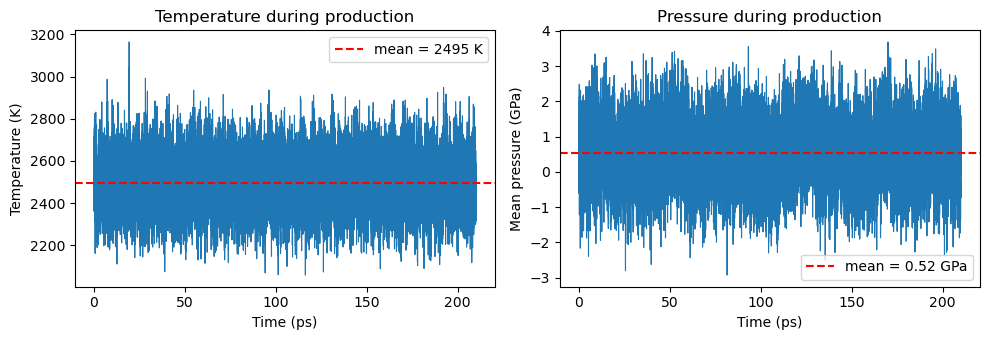

In [7]:
production_data = sim_result["result"]
temperature_trace = np.array(production_data["temperature"])
steps = np.arange(len(temperature_trace))  # one frame per n_print steps
time_ps = steps * 1.0 / 1000.0  # timestep=1 fs, n_print=1 → 1 frame/fs

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

axes[0].plot(time_ps, temperature_trace, lw=0.8)
axes[0].axhline(
    np.mean(temperature_trace), color="red", linestyle="--", label=f"mean = {np.mean(temperature_trace):.0f} K"
)
axes[0].set_xlabel("Time (ps)")
axes[0].set_ylabel("Temperature (K)")
axes[0].set_title("Temperature during production")
axes[0].legend()

# Mean diagonal pressure (approximation of mean pressure)
pressures = np.array(production_data["pressures"])  # shape [N, 3, 3], GPa
mean_pressure = (pressures[:, 0, 0] + pressures[:, 1, 1] + pressures[:, 2, 2]) / 3.0
axes[1].plot(time_ps, mean_pressure, lw=0.8)
axes[1].axhline(np.mean(mean_pressure), color="red", linestyle="--", label=f"mean = {np.mean(mean_pressure):.2f} GPa")
axes[1].set_xlabel("Time (ps)")
axes[1].set_ylabel("Mean pressure (GPa)")
axes[1].set_title("Pressure during production")
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Method 1 — Green-Kubo / SACF

`get_viscosity()` computes the shear viscosity from the stress autocorrelation function
(SACF) using the Green-Kubo relation.

### Key parameters

| Parameter | Meaning |
|---|---|
| `timestep` | MD integration timestep in **fs** (must match the simulation) |
| `output_frequency` | Frames were written every `output_frequency` steps (`n_print` in simulation) |
| `max_lag` | Maximum correlation lag in **frames** (limits memory; set to `None` for full length) |
| `cutoff_method` | Algorithm for auto-detecting $\tau_{\mathrm{cut}}$: `'self_consistent'` (default), `'noise_threshold'`, `'cumulative_integral'` |

### Cutoff detection methods

- **`noise_threshold`** — stops at the first lag where $|\mathrm{SACF}| < \epsilon \cdot \mathrm{SACF}(0)$
  for `consecutive` points. Fast, can be aggressive.
- **`cumulative_integral`** — stops when the running integral reaches $(1 - \epsilon)$ of its
  maximum. Robust when the SACF is monotonically decaying.
- **`self_consistent`** — Chodera-style: accepts $T$ as cutoff when
  $\tau_{\mathrm{acf}}(T) < T/c$. Most reliable for noisy SACFs.

> **Warning:** If $\tau_{\mathrm{acf}}$ is comparable to the trajectory length, the SACF
> has not fully decayed and the cutoff detection will hit the end of the data, giving an
> unreliable estimate. Use the Helfand method in that case.

In [8]:
sacf_result = get_viscosity(
    result=sim_result,
    timestep=1.0,
    output_frequency=1,
    max_lag=1_000_000,
    cutoff_method="noise_threshold",
)

print(f"SACF viscosity  : {sacf_result['viscosity']:.4e} Pa·s")
print(f"τ_acf detected  : {sacf_result['tau_acf_ps']:.3f} ps")
print(f"Max lag used    : {sacf_result['max_lag']} ps")
print(f"Temperature     : {sacf_result['temperature']:.1f} K")

SACF viscosity  : 2.7974e-02 Pa·s
τ_acf detected  : 19.988 ps
Max lag used    : 42 ps
Temperature     : 2495.1 K


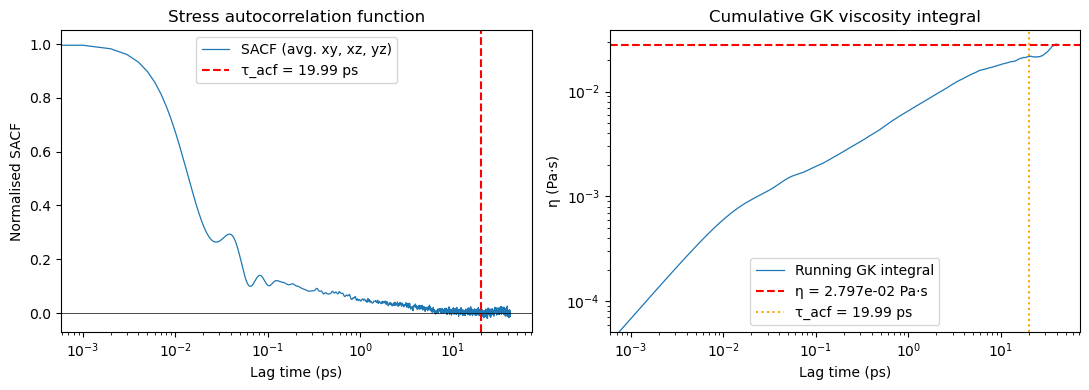

In [9]:
sacf_lag = np.array(sacf_result["lag_time_ps"])
sacf_values = np.array(sacf_result["sacf"])
viscosity_integral = np.array(sacf_result["viscosity_integral"])
tau_acf = sacf_result["tau_acf_ps"]
sacf_eta = sacf_result["viscosity"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left: normalised SACF
axes[0].plot(sacf_lag, sacf_values, lw=0.9, label="SACF (avg. xy, xz, yz)")
axes[0].axvline(tau_acf, color="red", linestyle="--", label=f"τ_acf = {tau_acf:.2f} ps")
axes[0].axhline(0, color="black", lw=0.5)
axes[0].set_xscale("log")
axes[0].set_xlabel("Lag time (ps)")
axes[0].set_ylabel("Normalised SACF")
axes[0].set_title("Stress autocorrelation function")
axes[0].legend()

# Right: running GK integral
axes[1].plot(sacf_lag, viscosity_integral, lw=0.9, label="Running GK integral")
axes[1].axhline(sacf_eta, color="red", linestyle="--", label=f"η = {sacf_eta:.3e} Pa·s")
axes[1].axvline(tau_acf, color="orange", linestyle=":", label=f"τ_acf = {tau_acf:.2f} ps")
axes[1].set_xlabel("Lag time (ps)")
axes[1].set_ylabel("η (Pa·s)")
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_title("Cumulative GK viscosity integral")
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Method 2 — Helfand moment

`helfand_viscosity()` computes the shear viscosity from the mean-square displacement
of the Helfand moments $\chi_{\alpha\beta}(t)$.

### Algorithm

1. Compute the Helfand moments by cumulative summation:
   $\chi_{\alpha\beta}^{(n)} = \sum_{k=0}^{n} P_{\alpha\beta}(k) \cdot \Delta t$
2. Calculate the MSD of each moment via FFT (equivalent to the full $O(N^2)$ loop
   but $O(N \log N)$ in practice).
3. Average the MSD over the three off-diagonal components $(xy, xz, yz)$.
4. Fit a line to the MSD in the **diffusive regime** — the region starting well after
   the stress relaxation time $\tau_{\mathrm{stress}}$ (estimated automatically from the
   pressure ACF half-decay time).
5. Extract viscosity from the slope: $\eta = \mathrm{slope} \cdot V / (2 k_B T)$.

### Key parameters

| Parameter | Meaning |
|---|---|
| `timestep` | MD integration timestep in **fs** |
| `output_frequency` | Frames per step (`n_print`) |
| `max_lag` | Maximum lag in **frames** for the MSD calculation (default: `N // 2`) |

### Additional outputs

- **`shear_modulus_inf`** (Pa): $G_\infty = V / (k_B T) \cdot \langle P_{\alpha\beta}^2 \rangle$
  — the instantaneous shear modulus of the melt. Physically large (~10–100 GPa) even
  for liquids because it measures the response at time zero, before structural relaxation.
- **`maxwell_relaxation_time_ps`** (ps): $\tau_M = \eta / G_\infty$ — should be in the
  ps range for liquids above the glass transition.
- **`bulk_viscosity`** (Pa·s): from the isotropic pressure deviation SACF.

In [22]:
helfand_result = helfand_viscosity(
    result=sim_result,
    timestep=1.0,
    output_frequency=1,
    max_lag=10_000,
)

print(f"Helfand viscosity   : {helfand_result['viscosity']:.4e} Pa·s")
print(f"Uncertainty (1\u03c3)    : {helfand_result['viscosity_fit_residual']:.4e} Pa·s")
print(f"Temperature         : {helfand_result['temperature']:.1f} K")
print(f"G∞                  : {helfand_result['shear_modulus_inf'] / 1e9:.2f} GPa")
print(f"Maxwell τ_M         : {helfand_result['maxwell_relaxation_time_ps']:.3f} ps")
print(f"Bulk viscosity      : {helfand_result['bulk_viscosity']:.4e} Pa·s")
print(f"Mean pressure       : {helfand_result['mean_pressure_gpa']:.3f} GPa")

Helfand viscosity   : 6.3223e-03 Pa·s
Uncertainty (1σ)    : 4.6665e-15 Pa·s
Temperature         : 2495.1 K
G∞                  : 68.48 GPa
Maxwell τ_M         : 0.092 ps
Bulk viscosity      : 2.3131e-02 Pa·s
Mean pressure       : 0.524 GPa


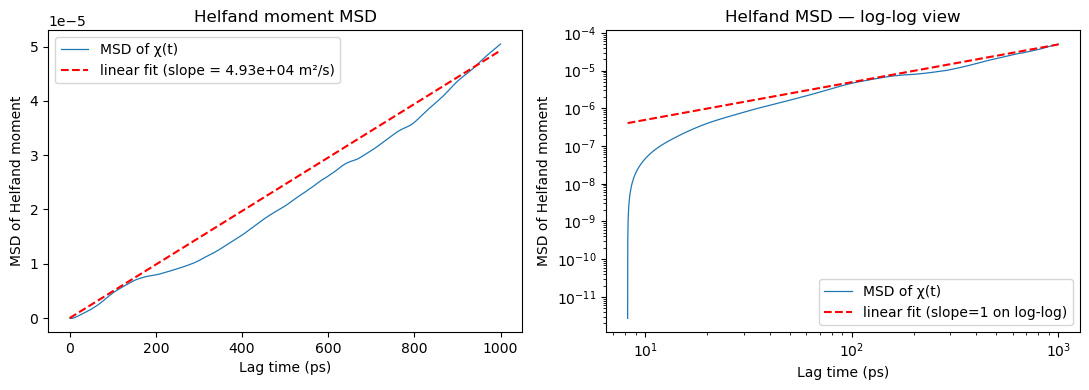

Interpretation:
  Short lags (t << τ_stress): MSD ∝ t²  (ballistic regime — slope=2 on log-log)
  Long lags  (t >> τ_stress): MSD ∝ t   (diffusive regime — slope=1 on log-log)
  Viscosity is extracted from the diffusive regime.


In [8]:
helfand_lag = np.array(helfand_result["lag_time_ps"])
helfand_msd = np.array(helfand_result["msd"])
helfand_slope = helfand_result["slope"]
helfand_eta = helfand_result["viscosity"]

# Reconstruct the fit line (slope in m²/s, lag in ps → convert to m²)
lag_s = helfand_lag * 1e-12
fit_line = helfand_slope * lag_s

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left: MSD of Helfand moments
axes[0].plot(helfand_lag, helfand_msd, lw=0.9, label="MSD of χ(t)")
axes[0].plot(helfand_lag, fit_line, color="red", linestyle="--", label=f"linear fit (slope = {helfand_slope:.2e} m²/s)")
axes[0].set_xlabel("Lag time (ps)")
axes[0].set_ylabel("MSD of Helfand moment")
axes[0].set_title("Helfand moment MSD")
axes[0].legend()

# Right: same on log-log to see ballistic → diffusive transition
pos_mask = (helfand_msd > 0) & (helfand_lag > 0)
axes[1].loglog(helfand_lag[pos_mask], helfand_msd[pos_mask], lw=0.9, label="MSD of χ(t)")
axes[1].loglog(
    helfand_lag[pos_mask], fit_line[pos_mask], color="red", linestyle="--", label="linear fit (slope=1 on log-log)"
)
axes[1].set_xlabel("Lag time (ps)")
axes[1].set_ylabel("MSD of Helfand moment")
axes[1].set_title("Helfand MSD — log-log view")
axes[1].legend()

plt.tight_layout()
plt.show()

print("Interpretation:")
print("  Short lags (t << τ_stress): MSD ∝ t²  (ballistic regime — slope=2 on log-log)")
print("  Long lags  (t >> τ_stress): MSD ∝ t   (diffusive regime — slope=1 on log-log)")
print("  Viscosity is extracted from the diffusive regime.")

## 6. Side-by-side comparison

Both methods should give consistent viscosity estimates when the trajectory is long enough
for the SACF to decay and for the Helfand MSD to enter the diffusive regime.

At **short** trajectory lengths (as in this demo):

- **SACF/GK** may under-estimate η because the SACF is cut off before it fully decays
  to zero (or the auto-cutoff fires too early).
- **Helfand** may be unreliable because the MSD has not entered the linear regime and
  the fit is extrapolating.

This is expected and is the reason production runs need 10–100 ns.

Method                      η (Pa·s)   Notes
----------------------------------------------------------
Green-Kubo (SACF)         2.7974e-02   τ_acf = 19.99 ps
Helfand                   6.3223e-03   σ = 4.67e-15 Pa·s



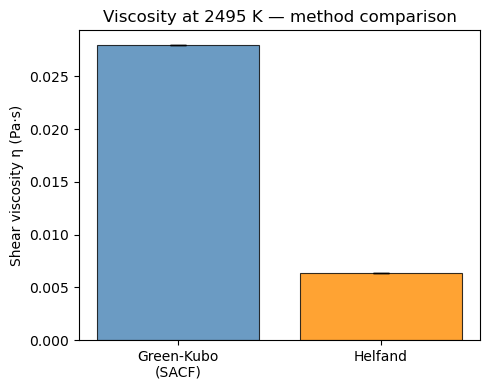

In [23]:
print("=" * 58)
print(f"{'Method':<22} {'η (Pa·s)':>13}   Notes")
print("-" * 58)
print(f"{'Green-Kubo (SACF)':<22} {sacf_result['viscosity']:>13.4e}   τ_acf = {sacf_result['tau_acf_ps']:.2f} ps")
print(
    f"{'Helfand':<22} {helfand_result['viscosity']:>13.4e}   \u03c3 = {helfand_result['viscosity_fit_residual']:.2e} Pa·s"
)
print("=" * 58)
print()

# Visual bar chart comparison
methods = ["Green-Kubo\n(SACF)", "Helfand"]
values = [sacf_result["viscosity"], helfand_result["viscosity"]]
errors = [0.0, helfand_result["viscosity_fit_residual"]]

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(
    methods,
    values,
    yerr=errors,
    capsize=6,
    color=["steelblue", "darkorange"],
    alpha=0.8,
    edgecolor="black",
    linewidth=0.8,
)
ax.set_ylabel("Shear viscosity η (Pa·s)")
ax.set_title(f"Viscosity at {sacf_result['temperature']:.0f} K — method comparison")
# ax.set_yscale("log")
# for bar, val in zip(bars, values):
#    ax.text(bar.get_x() + bar.get_width() / 2, val * 1.5,
#            f"{val:.2e}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

## 7. Ensemble averaging with `viscosity_ensemble`

A single MD trajectory gives only one noisy estimate of η because the stress fluctuations
are inherently statistical. Running **N independent replicas** with different random
velocity seeds and averaging their viscosities reduces the uncertainty by $\sqrt{N}$.

`viscosity_ensemble` wraps `viscosity_simulation` for each replica and returns:

- `viscosity` — mean η across replicas
- `viscosity_sem` — standard error of the mean (SEM = std / √N)
- `viscosity_fit_residual` — sample standard deviation
- `viscosities` — per-replica η values
- `converged` — per-replica convergence flag
- `G∞`, `τ_M`, bulk viscosity averaged over replicas

### Execution modes

| Mode | How to invoke | When to use |
|---|---|---|
| Sequential | default | development, few replicas |
| Local parallel | `parallel=True` | workstation with many cores |
| HPC cluster | `executor=SlurmJobExecutor(...)` | 10–100 replicas on a cluster |

> **Note:** The `parallel=True` mode uses a `ThreadPoolExecutor`. Each replica spawns
> a separate MPI LAMMPS process, which releases the GIL, so Python threading works correctly.

In [10]:
with SingleNodeExecutor(cache_directory="./tutorial_ensemble_cache") as exe:
    ensemble_future = exe.submit(
        viscosity_ensemble,
        structure=structure,
        potential=potential,
        n_replicas=3,
        temperature_sim=3000,
        timestep=1.0,
        initial_production_steps=10_000,  # demo: use ≥10_000_000 for production
        n_print=1,
        max_total_time_ns=0.1,  # demo: use ≥10 for production
        max_iterations=3,
        server_kwargs={"cores": 2},
        parallel=True,
        tmp_working_directory="./tutorial_ensemble_cache",
    )
    ensemble_result = ensemble_future.result()

print(
    f"η = {ensemble_result['viscosity']:.4e} ± {ensemble_result['viscosity_sem']:.4e} Pa·s"
    f"  (n = {ensemble_result['n_replicas']} replicas)"
)
print(f"std across replicas : {ensemble_result['viscosity_fit_residual']:.4e} Pa·s")
print(f"G∞ (mean)           : {ensemble_result['shear_modulus_inf'] / 1e9:.2f} GPa")
print(f"τ_M (mean)          : {ensemble_result['maxwell_relaxation_time_ps']:.3f} ps")
print(f"Bulk viscosity      : {ensemble_result['bulk_viscosity']:.4e} Pa·s")
print()
print("Per-replica results:")
for i, (eta_i, conv_i, seed_i) in enumerate(
    zip(ensemble_result["viscosities"], ensemble_result["converged"], ensemble_result["seeds"])
):
    print(f"  Replica {i + 1}: η = {eta_i:.4e} Pa·s  converged={conv_i}  seed={seed_i}")

η = 7.9384e-03 ± 1.1744e-03 Pa·s  (n = 3 replicas)
std across replicas : 2.0341e-03 Pa·s
G∞ (mean)           : 58.62 GPa
τ_M (mean)          : 0.135 ps
Bulk viscosity      : -4.4017e-03 Pa·s

Per-replica results:
  Replica 1: η = 8.6091e-03 Pa·s  converged=False  seed=629293528
  Replica 2: η = 5.6536e-03 Pa·s  converged=False  seed=204602420
  Replica 3: η = 9.5524e-03 Pa·s  converged=False  seed=709782289


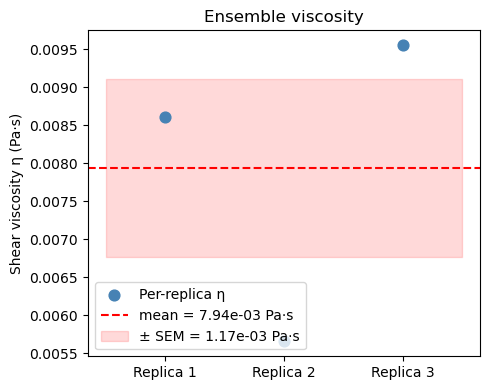

In [11]:
per_replica_viscosities = ensemble_result["viscosities"]
mean_eta = ensemble_result["viscosity"]
sem_eta = ensemble_result["viscosity_sem"]

fig, ax = plt.subplots(figsize=(5, 4))
replica_labels = [f"Replica {i + 1}" for i in range(len(per_replica_viscosities))]
ax.scatter(
    range(len(per_replica_viscosities)),
    per_replica_viscosities,
    color="steelblue",
    zorder=3,
    s=60,
    label="Per-replica η",
)
ax.axhline(mean_eta, color="red", linestyle="--", label=f"mean = {mean_eta:.2e} Pa·s")
ax.fill_between(
    [-0.5, len(per_replica_viscosities) - 0.5],
    [mean_eta - sem_eta] * 2,
    [mean_eta + sem_eta] * 2,
    color="red",
    alpha=0.15,
    label=f"± SEM = {sem_eta:.2e} Pa·s",
)
ax.set_xticks(range(len(per_replica_viscosities)))
ax.set_xticklabels(replica_labels)
ax.set_ylabel("Shear viscosity η (Pa·s)")
ax.set_title("Ensemble viscosity")
# ax.set_yscale("log")
ax.legend()
plt.tight_layout()
plt.show()

## 8. (Optional) VFT temperature scan

The Vogel-Fulcher-Tammann (VFT) equation describes the temperature dependence of
viscosity in supercooled liquids and glass-forming melts:

$$
\log_{10} \eta = \log_{10} \eta_0 + \frac{B}{T - T_0} \cdot \log_{10} e
$$

where $\eta_0$ is a pre-exponential factor, $B$ is an activation parameter (K),
and $T_0$ is the Vogel temperature. Fitting requires at least three temperature points.

The cell below shows the **workflow pattern** — run `viscosity_ensemble` at each
temperature with production-quality settings, collect the mean viscosities, then fit.
Replace the stub values with real simulation outputs.

In [12]:
# --- VFT workflow stub ---
# Uncomment and run with production-quality simulation parameters.

# temperatures_K = [3000, 3500, 4000, 4500, 5000]  # K
# viscosity_values = []

# for T in temperatures_K:
#     with SingleNodeExecutor(cache_directory=f"./vft_cache_T{T}") as exe:
#         res_future = exe.submit(
#             viscosity_ensemble,
#             structure=structure,
#             potential=potential,
#             n_replicas=5,
#             temperature_sim=T,
#             timestep=1.0,
#             initial_production_steps=10_000_000,  # 10 ns
#             n_print=1,
#             max_total_time_ns=50,
#             max_iterations=40,
#             server_kwargs={"cores": 4},
#             parallel=True,
#         )
#         res = res_future.result()
#     viscosity_values.append(res["viscosity"])
#     print(f"T = {T} K:  η = {res['viscosity']:.4e} ± {res['viscosity_sem']:.4e} Pa·s")

# log10_viscosities = np.log10(viscosity_values)
# popt, pcov = fit_vft(temperatures_K, log10_viscosities)
# log10_eta0, B, T0 = popt
# print(f"\nVFT fit:  log10η₀ = {log10_eta0:.2f},  B = {B:.0f} K,  T₀ = {T0:.0f} K")

# # Plot
# T_fit = np.linspace(min(temperatures_K), max(temperatures_K), 200)
# from amorphouspy.workflows.viscosity import vft_model
# fig, ax = plt.subplots(figsize=(5, 4))
# ax.scatter(10000 / np.array(temperatures_K), log10_viscosities,
#            zorder=3, label="Simulation")
# ax.plot(10000 / T_fit, vft_model(T_fit, *popt), label="VFT fit")
# ax.set_xlabel("10000 / T  (K⁻¹)")
# ax.set_ylabel("log₁₀ η  (Pa·s)")
# ax.set_title("VFT temperature dependence")
# ax.legend()
# plt.tight_layout()
# plt.show()

print("VFT workflow stub — uncomment and replace with production simulation settings.")

VFT workflow stub — uncomment and replace with production simulation settings.


## 9. HPC cluster usage

For large ensembles (e.g. 100 replicas × 6 cores = 600 cores), submitting jobs manually
to SLURM is impractical. Pass any executorlib executor as the `executor` argument to
have `viscosity_ensemble` submit replicas automatically.

executorlib reads the `resource_dict` from the executor constructor to build the
`sbatch` script for each replica — no manual scripting required.

### Mode 1: Each replica as its own SLURM job (`SlurmJobExecutor`)

Best when you want maximum parallelism and replicas are long-running (hours).
100 replicas × 6 cores = 600 cores distributed across 13 × 48-core nodes.

```python
from executorlib import SlurmJobExecutor
from amorphouspy import viscosity_ensemble

with SlurmJobExecutor(
    max_workers=100,
    resource_dict={
        "cores": 6,
        "partition": "compute",
        "run_time_limit": 86400,   # 24 h in seconds
        "memory_max": 16,          # GB per job
    },
) as exe:
    result = viscosity_ensemble(
        structure=structure,
        potential=potential,
        n_replicas=100,
        temperature_sim=3000,
        timestep=1.0,
        initial_production_steps=10_000_000,  # 10 ns
        server_kwargs={"cores": 6},
        executor=exe,
        tmp_working_directory="./viscosity_hpc_cache",
    )

print(f"{result['viscosity']:.4e} ± {result['viscosity_sem']:.4e} Pa·s")
# 100 replicas × 6 cores = 600 cores across cluster nodes, SLURM scripts auto-generated
```

### Mode 2: All replicas within a shared SLURM allocation (`SlurmClusterExecutor`)

Best when you have a fixed allocation and want to fill it efficiently.

```python
from executorlib import SlurmClusterExecutor

with SlurmClusterExecutor(max_cores=600) as exe:
    result = viscosity_ensemble(
        ...,
        n_replicas=100,
        server_kwargs={"cores": 6},
        executor=exe,
    )
```

### Seed reproducibility

Seeds used for each replica are saved to
`tmp_working_directory/viscosity_ensemble_seeds.json` immediately after generation,
so you can reproduce any replica even if the run is interrupted.

```python
import json
seeds_info = json.load(open("./viscosity_hpc_cache/viscosity_ensemble_seeds.json"))
print(seeds_info["seeds"])  # list of 100 integers
```

Pass them back via `seeds=[...]` to re-run exactly the same replicas.
